# 机器学习第一节课作业:线性回归

## 1.单变量线性回归

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
path = r'C:\Users\guoqi\Desktop\EXdata\ex1data1.txt'
data = pd.read_csv(path, header=None, names=['Population', 'Profit'])
data.head()

,Population,Profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [57]:
data.describe()

,Population,Profit
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


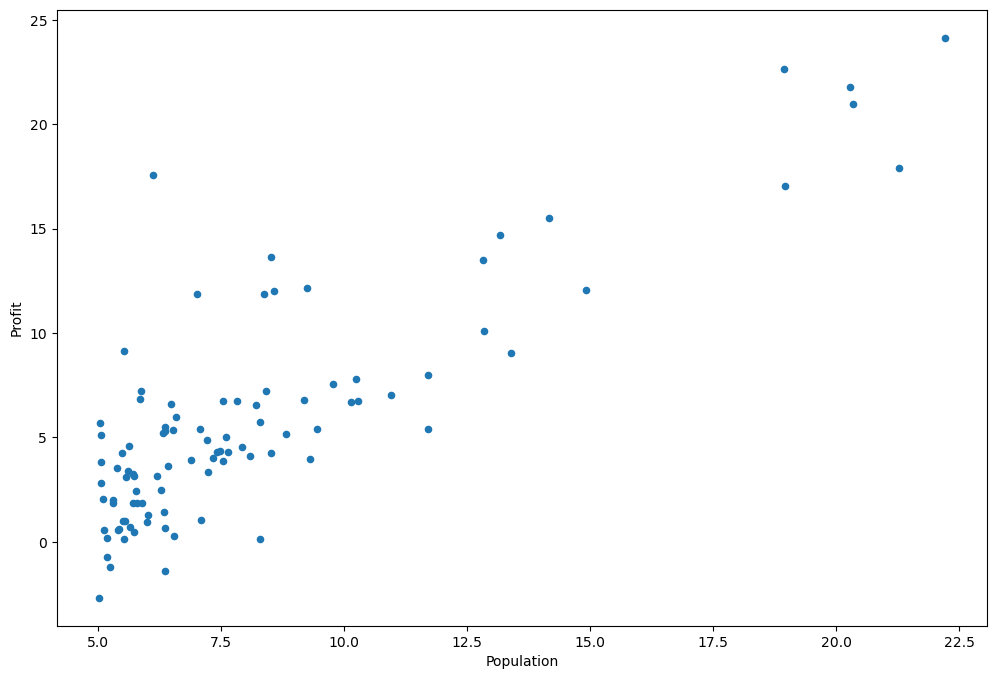

In [58]:
data.plot(kind='scatter', x='Population', y='Profit', figsize=(12,8))
plt.show()

In [59]:
data.insert(0, 'Ones', 1)

左闭右开区间

In [60]:
#set X (training data) and Y (target variable)
cols = data.shape[1]
X = data.iloc[:,0:cols-1]
y = data.iloc[:,cols-1:cols]

In [61]:
X.head()

,Ones,Population
0,1,6.1101
1,1,5.5277
2,1,8.5186
3,1,7.0032
4,1,5.8598


In [62]:
y.head()

,Profit
0,17.5920
1,9.1302
2,13.6620
3,11.8540
4,6.8233


代价函数是应该是numpy矩阵，所以我们需要转换X和Y，然后才能使用它们。我们还需要初始化theta，即把theta所有元素都设置为0.

In [63]:
X = np.matrix(X.values)
y = np.matrix(y.values)
#you code here  (appro ~1 lines)
theta = np.matrix(np.array([0,0]))

theta是一个(1,2)的矩阵

In [64]:
theta

matrix([[0, 0]])

In [65]:
def computerCost(X ,y , theta):
    #your code here (appro ~2 lines)
    inner = np.power(((X * theta.T)-y), 2)
    return np.sum(inner)/(2*len(X))

In [66]:
X.shape, y.shape, theta.shape

((97, 2), (97, 1), (1, 2))

In [67]:
computerCost(X ,y ,theta )

32.072733877455676

 ## 2.batch gradient descent (批量梯度下降)

$$
\theta _j := \theta _j - \alpha \frac{\partial }{\partial \theta _j} J(\theta )
$$

In [68]:
def gradientDescent(X ,y , theta, alpha, iters):
    temp = np.matrix(np.zeros(theta.shape))  #构建零值矩阵
    parameters = int(theta.ravel().shape[1])  #ravel计算需要求解的参数个数 功能是将多维数组降至一维
    cost = np.zeros(iters)
    
    for i in range(iters):
        #your code here (appro ~1 lines)
        error = (X * theta.T) - y
        for j in range(parameters):
            #your code here  (appro ~2 lines)
            term = np.multiply(error, X[:,j])  #计算两矩阵(h(theta)(x) - y)x
            temp[0,j] = theta[0,j] - ((alpha/ len(X)) * np.sum(term))
            
        #your code here  (appro ~2 lines)
        theta = temp
        cost[i] = computerCost(X, y, theta)
    return theta, cost

初始化一些附加变量-学习速率a和要执行的选代次数。

In [69]:
alpha = 0.01
iters = 1000

现在让我们运行梯度下降算法来将我们的参数0适合于训练集。

In [70]:
g, cost = gradientDescent(X, y ,theta, alpha, iters)
g

matrix([[-3.24140214,  1.1272942 ]])

最后，我们可以使用我们拟合的参数计算训练模型的代价函数(误差)。

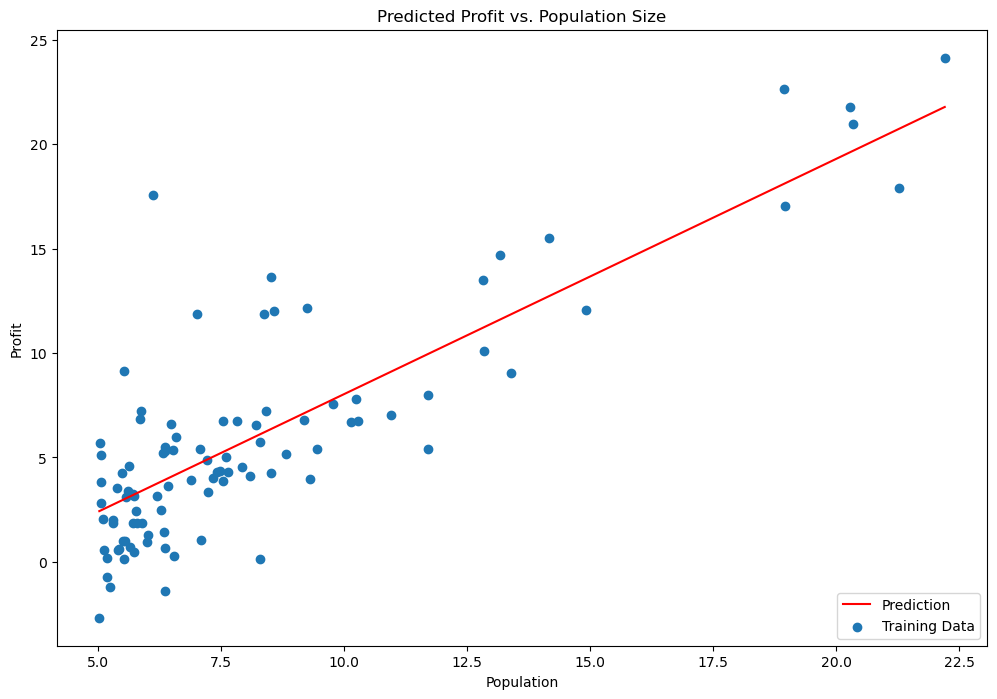

In [71]:
x = np.linspace(data.Population.min(), data.Population.max(), 100) #抽100个样本
f = g[0,0] + (g[0,1] * x) #g[0,0]代表theta0, g[0,1]代表theta1

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x, f, 'r', label='Prediction')
ax.scatter(data.Population, data.Profit, label='Training Data')
ax.legend(loc=4)#显示标签位置
ax.set_xlabel('Population')
ax.set_ylabel('Profit')
ax.set_title('Predicted Profit vs. Population Size')
plt.show()

由于梯度方程式函数也在每个训练迭代中输出一个代价的向量，所以我们也可以绘制。 请注意，代价总是降低-这是凸优化问题的一个例子。

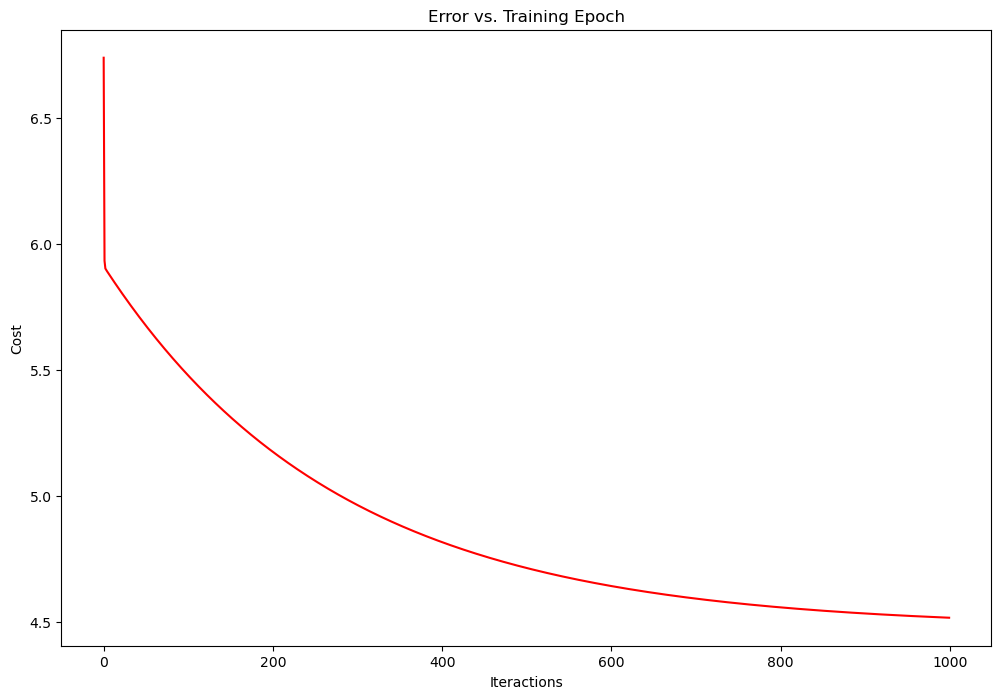

In [72]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(np.arange(iters), cost, 'r')
ax.set_xlabel('Iteractions')
ax.set_ylabel('Cost')
ax.set_title('Error vs. Training Epoch')
plt.show()

## 多变量线性回归



In [73]:
path = r'C:\Users\guoqi\Desktop\EXdata\ex1data2.txt'
data2 = pd.read_csv(path, header=None, names=['Size', 'Bedrooms', 'Price'])
data2.head()

,Size,Bedrooms,Price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


对于此任务，我们添加了另一个预处理步骤-特征归一化。这个对于pandas来说很简单

如果这个房子价格不归一化，它的数量级和你输入值规一化数量级差别太大，几十万的数量级和个位小数做回归，就不能保证收敛了预测的y和实际上y几十万差的

In [74]:
data2 = (data2 - data2.mean()) / data2.std() #特征归一化:(数据-均值) / 方差
data2.head()

,Size,Bedrooms,Price
0,0.130010,-0.223675,0.475747
1,-0.504190,-0.223675,-0.084074
2,0.502476,-0.223675,0.228626
3,-0.735723,-1.537767,-0.867025
4,1.257476,1.090417,1.595389


现在我们重复第1部分的预处理步骤，并对新数据集运行线性回归程序。

In [75]:
# add ones columns
data2.insert(0, 'Ones', 1)

# set X (Traning data) and y (target varible)
cols = data2.shape[1]
X2 = data2.iloc[:,0:cols-1]
y2 = data2.iloc[:,cols-1:cols]

#convert to matrices and initialine theta
X2 = np.matrix(X2.values)
y2 = np.matrix(y2.values)
theta2 = np.matrix(np.array([0,0,0]))

#perform linear regression on data set
g2, cost2 = gradientDescent(X2, y2, theta2, alpha=0.1, iters=1000)

#get the cost (error) of the model
computerCost(X2, y2, g2)

0.13068648053904197

## 4.normal equation (正则方程)

正则方程是通过求解下面的方程来找出使得代价函数最小的参数的:$\frac{\partial }{\partial \theta _j}J(\theta_j) = 0$. 假设我们的训练集特征矩阵为 X (包括了$x_0 = 1$)并且我们的训练集结果为向量y，则利用正规方程解出向量$\theta = (X^TX)^{-1}X^Ty$ . 上标T代表矩阵转置，上标-1代表矩阵的逆。设矩阵$A = X^TX$, 则:$(X^TX)^{-1} = A^{-1}$

梯度下降与正规方程的比较:
梯度下降:需要选择学习率a，需要多次迭代，当特征数量n大时也能较好适用，适用于各种类型的模型
正规方程:不需要选择学习率$\alpha$，一次计算得出，需要计算$(X^TX)^{-1}$，如果特征数量n较大则运算代价大，因为矩阵逆的计算时间复杂度为$O(n^3)$，通常来说当n小于10000 时还是可以接受的，只适用于线性模型，不适合逻辑回归模型等其他模型

np.linalg.inv求逆操作@相当于dot(), dot函数可以通过numpy库调用, 也可以由数组实例对象进行调用. a.dot(b)与np.dot(a,b)效果相同.

In [76]:
#正规方程
def normalEqn(X, y):
    theta = np.linalg.inv(X.T@X)@X.T@y
    return theta

In [77]:
final_theta2 = normalEqn(X,y)
final_theta2

matrix([[-3.89578088],
        [ 1.19303364]])